# CNN Results

Display-only notebook for showcasing CNN training run results.
Figures are pre-generated by `evaluate_cnn.py` — no model loading or retraining here.

To regenerate figures for a run:
```bash
python -m elp_rumble.evaluate_cnn --run_dir runs/cnn/<run_name>
```

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

FIGURES_DIR = Path("../results/figures")

# Point this at your completed run directory to load metrics
RUN_DIR = Path("../runs/cnn")  # update to specific run

## Test Metrics Summary

In [2]:
# Find the most recent run if RUN_DIR points to runs/cnn/
if not (RUN_DIR / "test_metrics.json").exists():
    runs = sorted(RUN_DIR.glob("*/test_metrics.json"), key=lambda p: p.stat().st_mtime)
    if not runs:
        print("No completed runs found. Run train_cnn.py first.")
    else:
        metrics_path = runs[-1]
        print(f"Using run: {metrics_path.parent.name}")
else:
    metrics_path = RUN_DIR / "test_metrics.json"

with open(metrics_path) as f:
    metrics = json.load(f)

skip = {"confusion_matrix"}
rows = [(k, v) for k, v in metrics.items() if k not in skip]
pd.DataFrame(rows, columns=["Metric", "Value"]).set_index("Metric").style.format("{:.4f}")

Using run: model1_bs32_lr0.0001_e2_20260310_184705


,Value
Metric,
accuracy,0.7500
precision,0.0000
recall,0.0000
auc,0.7467
n_examples,20.0000


## Training Curves

Loss and AUC over epochs for both training and validation sets.

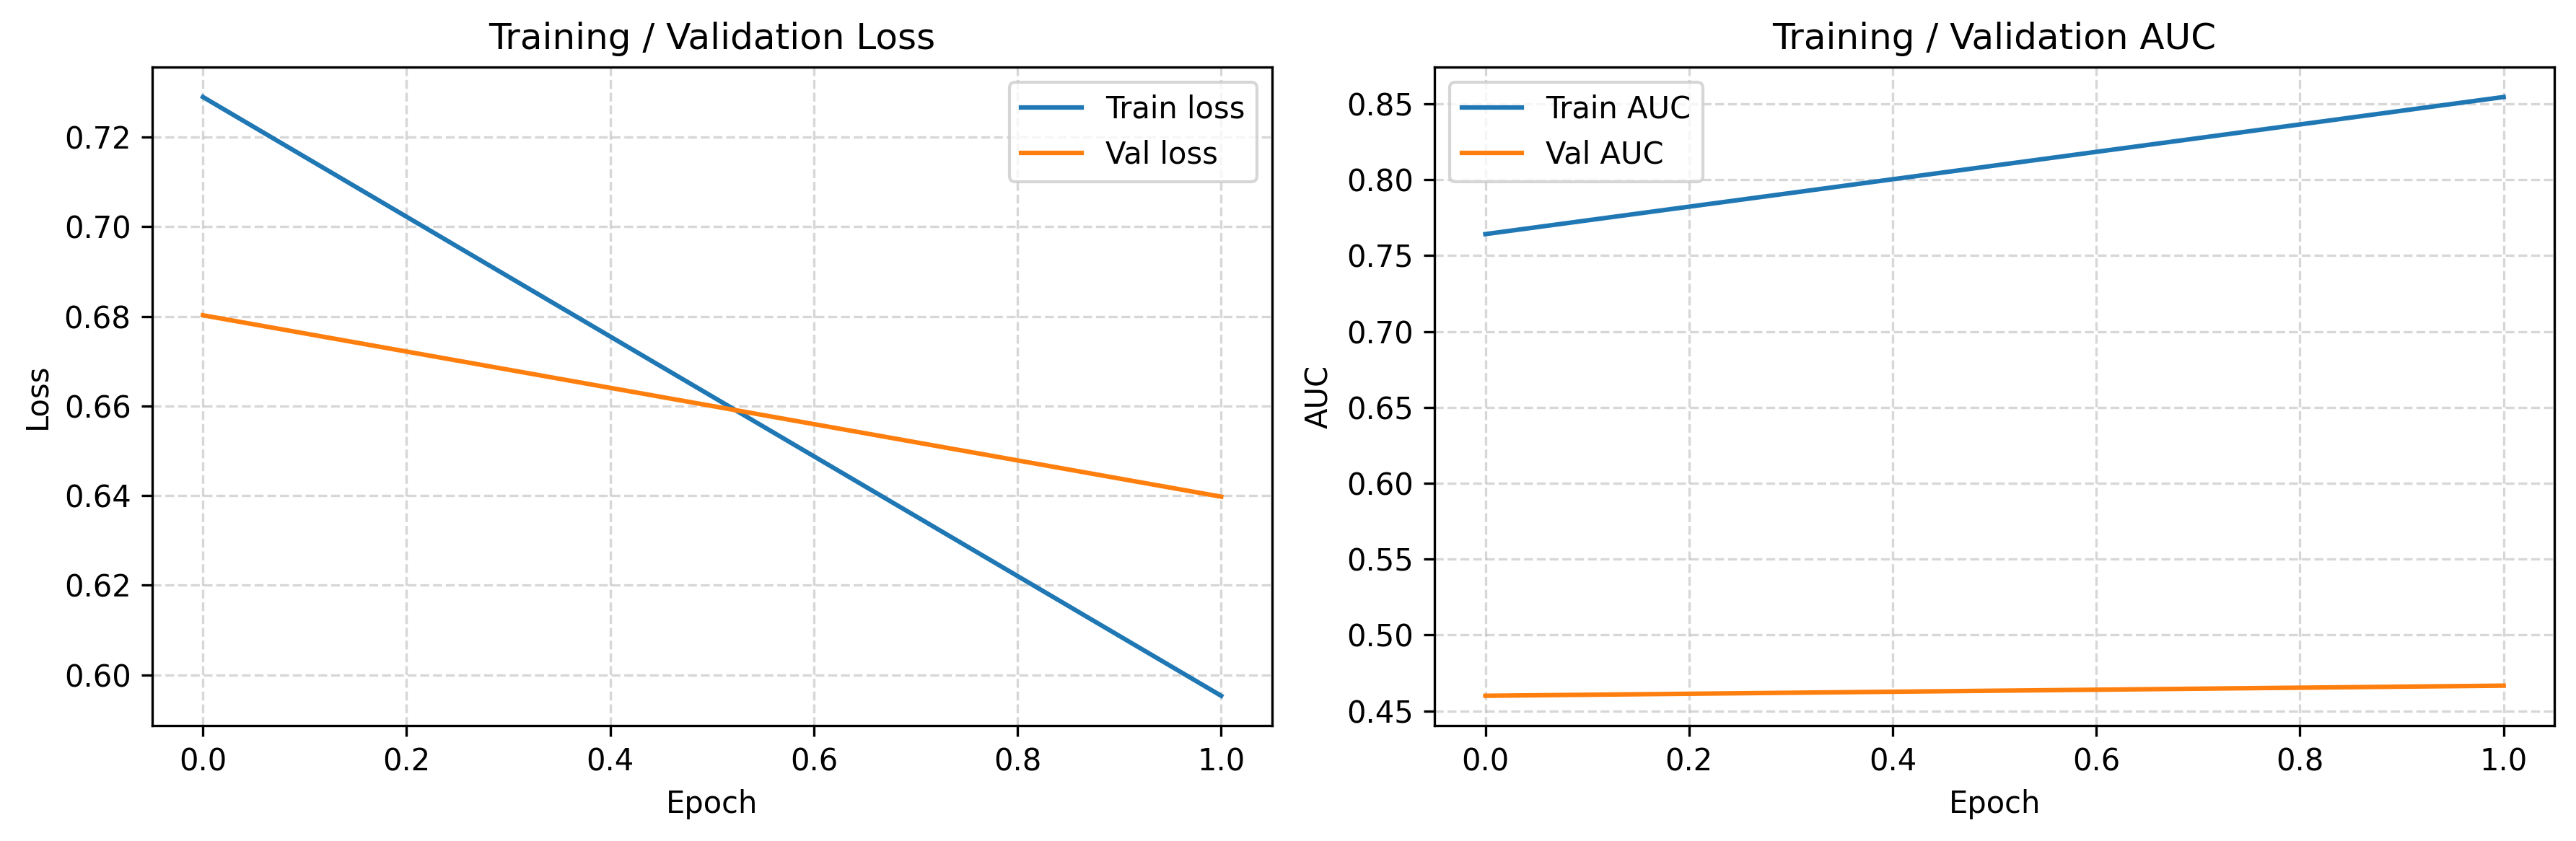

In [3]:
display(Image(filename=str(FIGURES_DIR / "training_curves.png")))

## Confusion Matrix

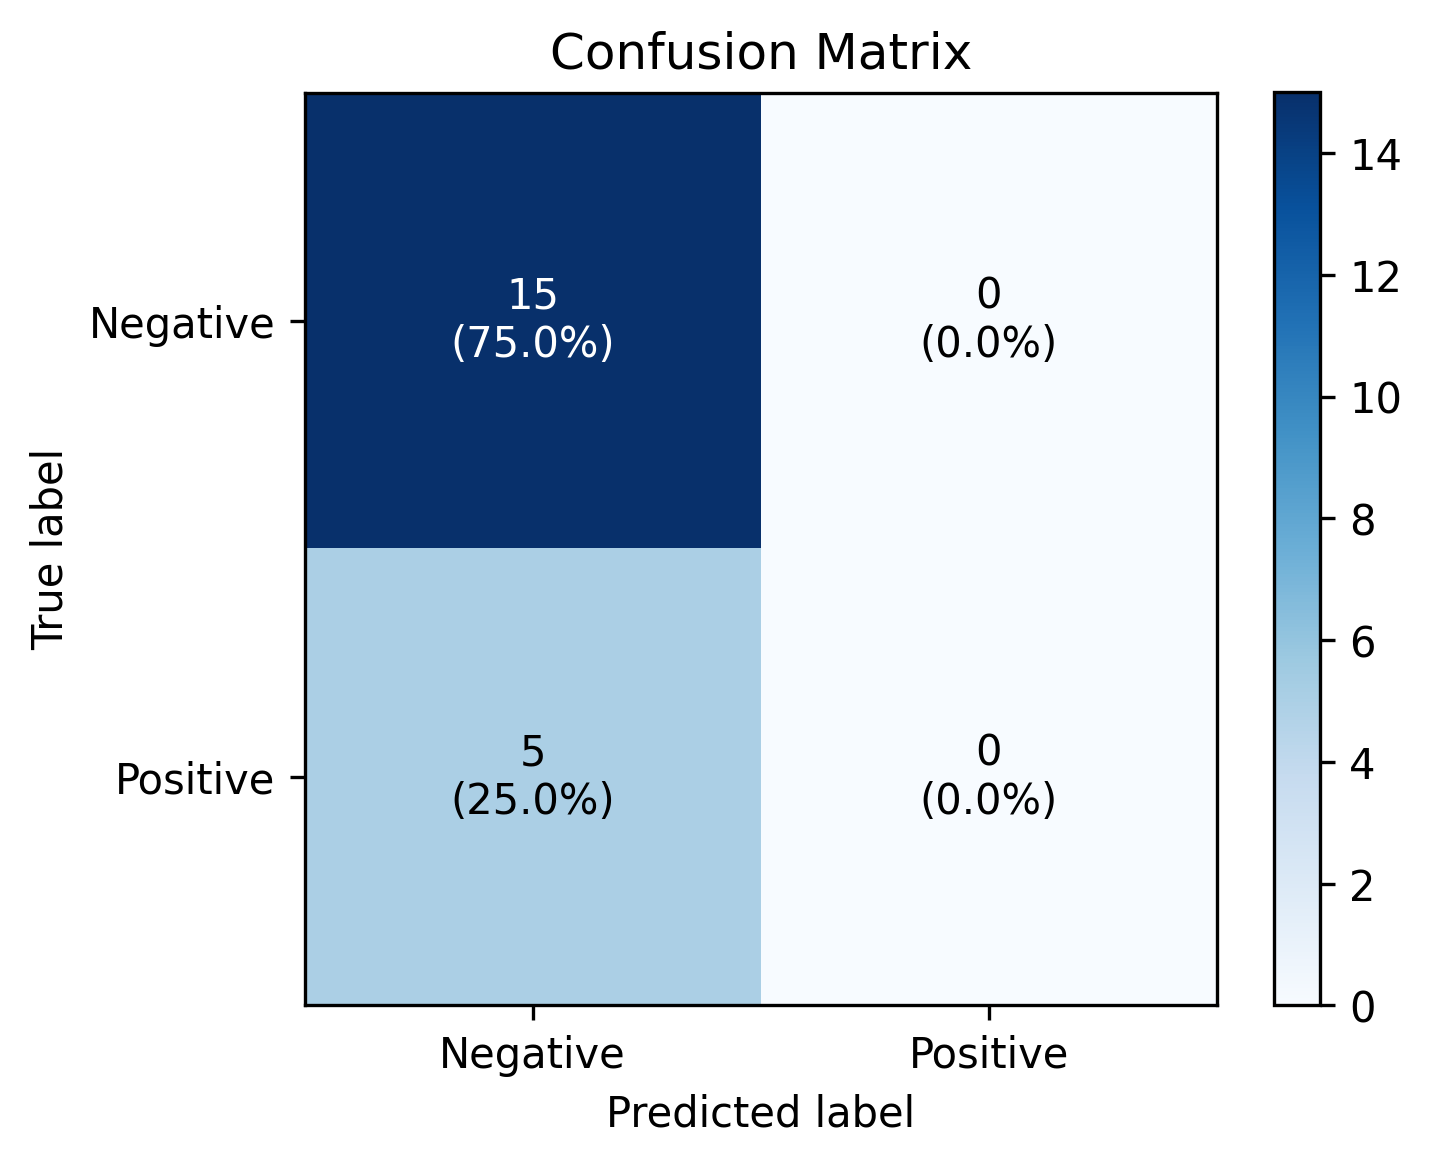

In [4]:
display(Image(filename=str(FIGURES_DIR / "confusion_matrix.png")))

## ROC Curve

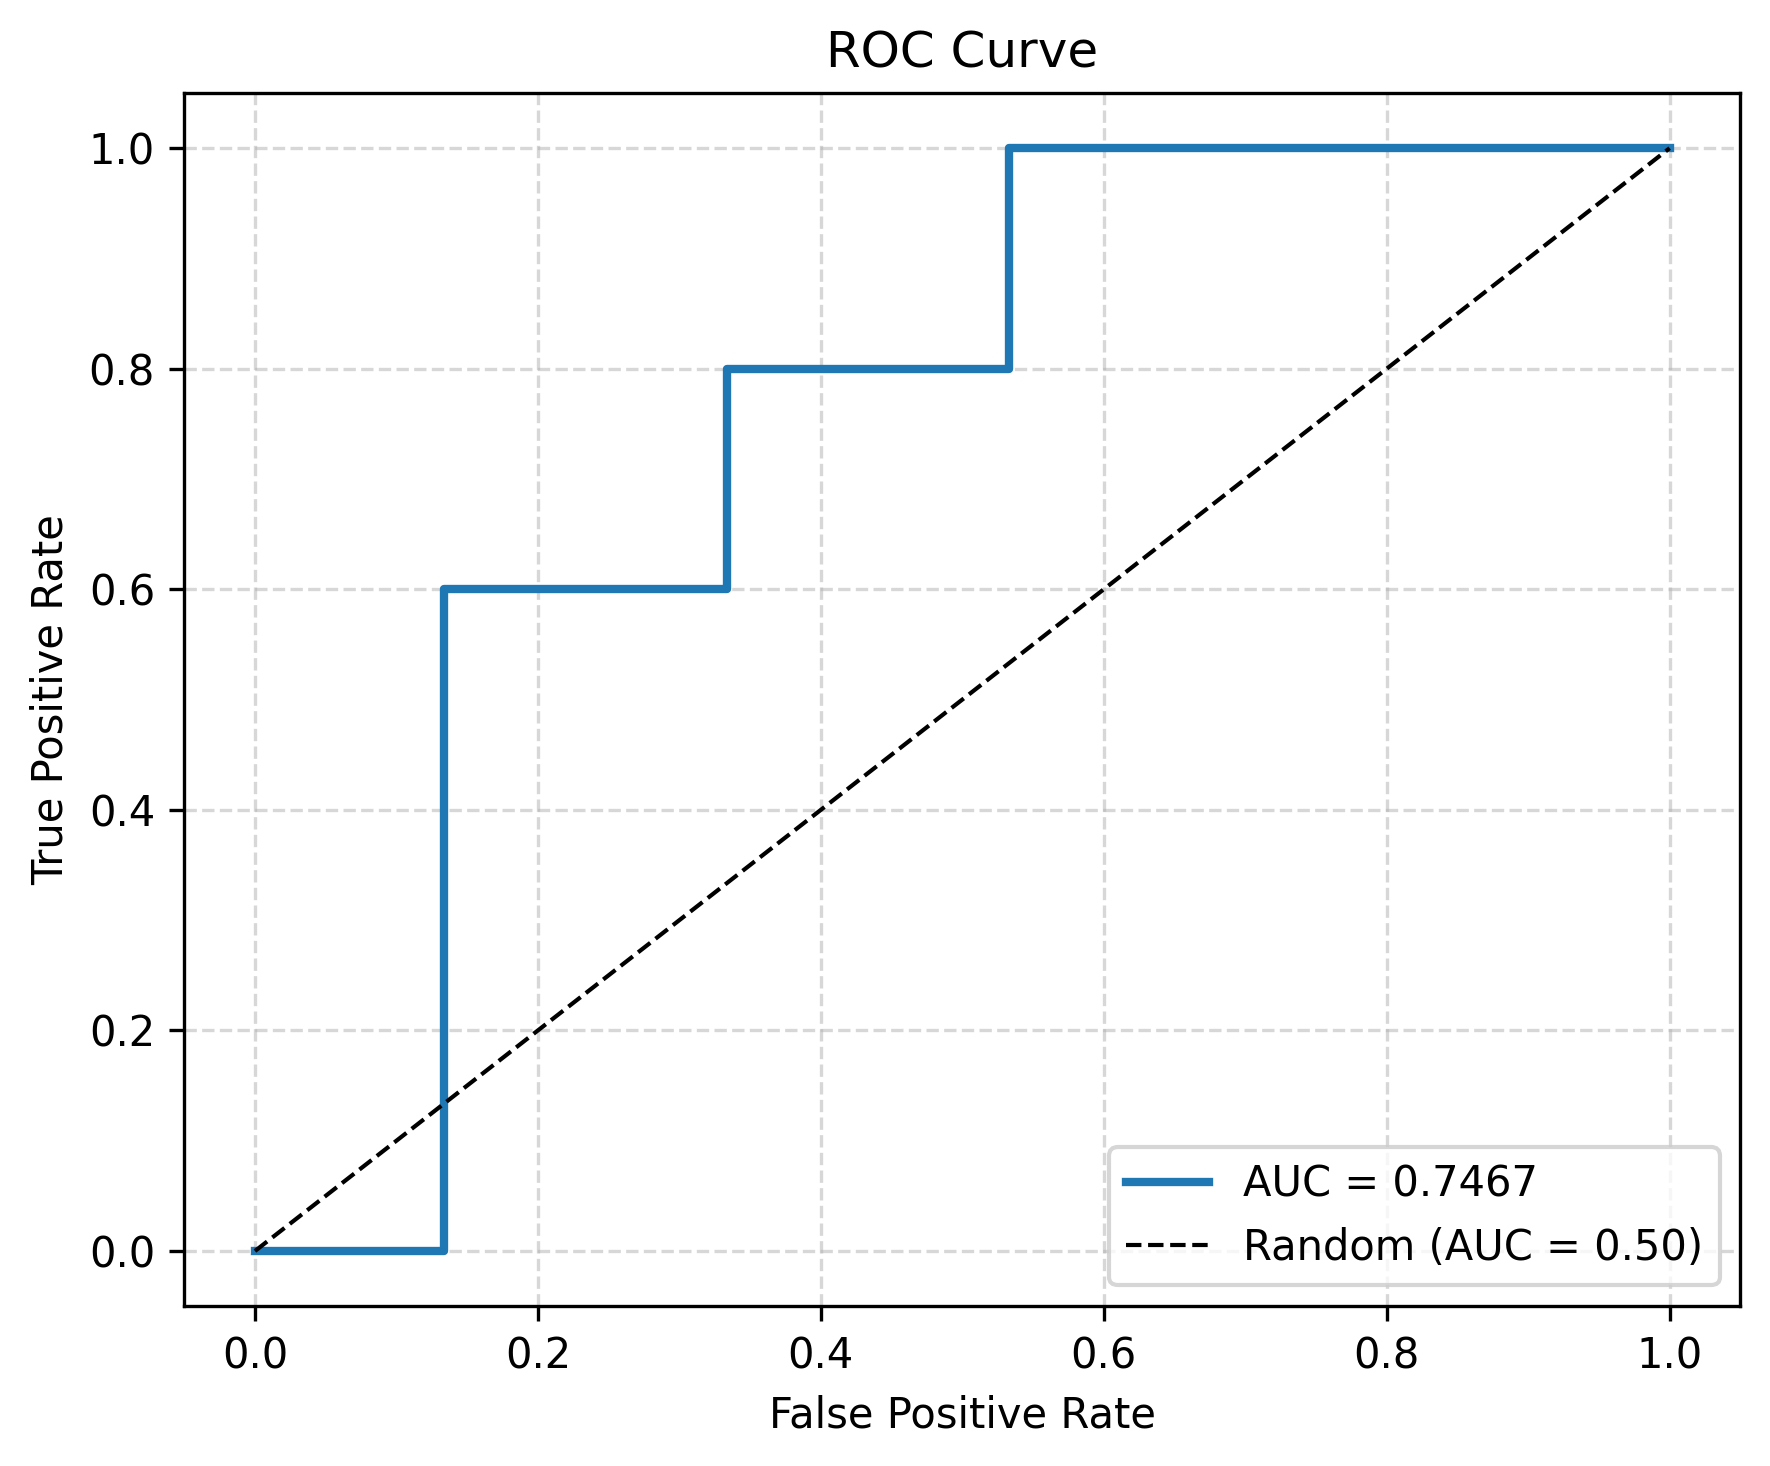

In [5]:
display(Image(filename=str(FIGURES_DIR / "roc_curve.png")))

## Precision-Recall Curve

Important given the 3:1 class imbalance in this dataset.

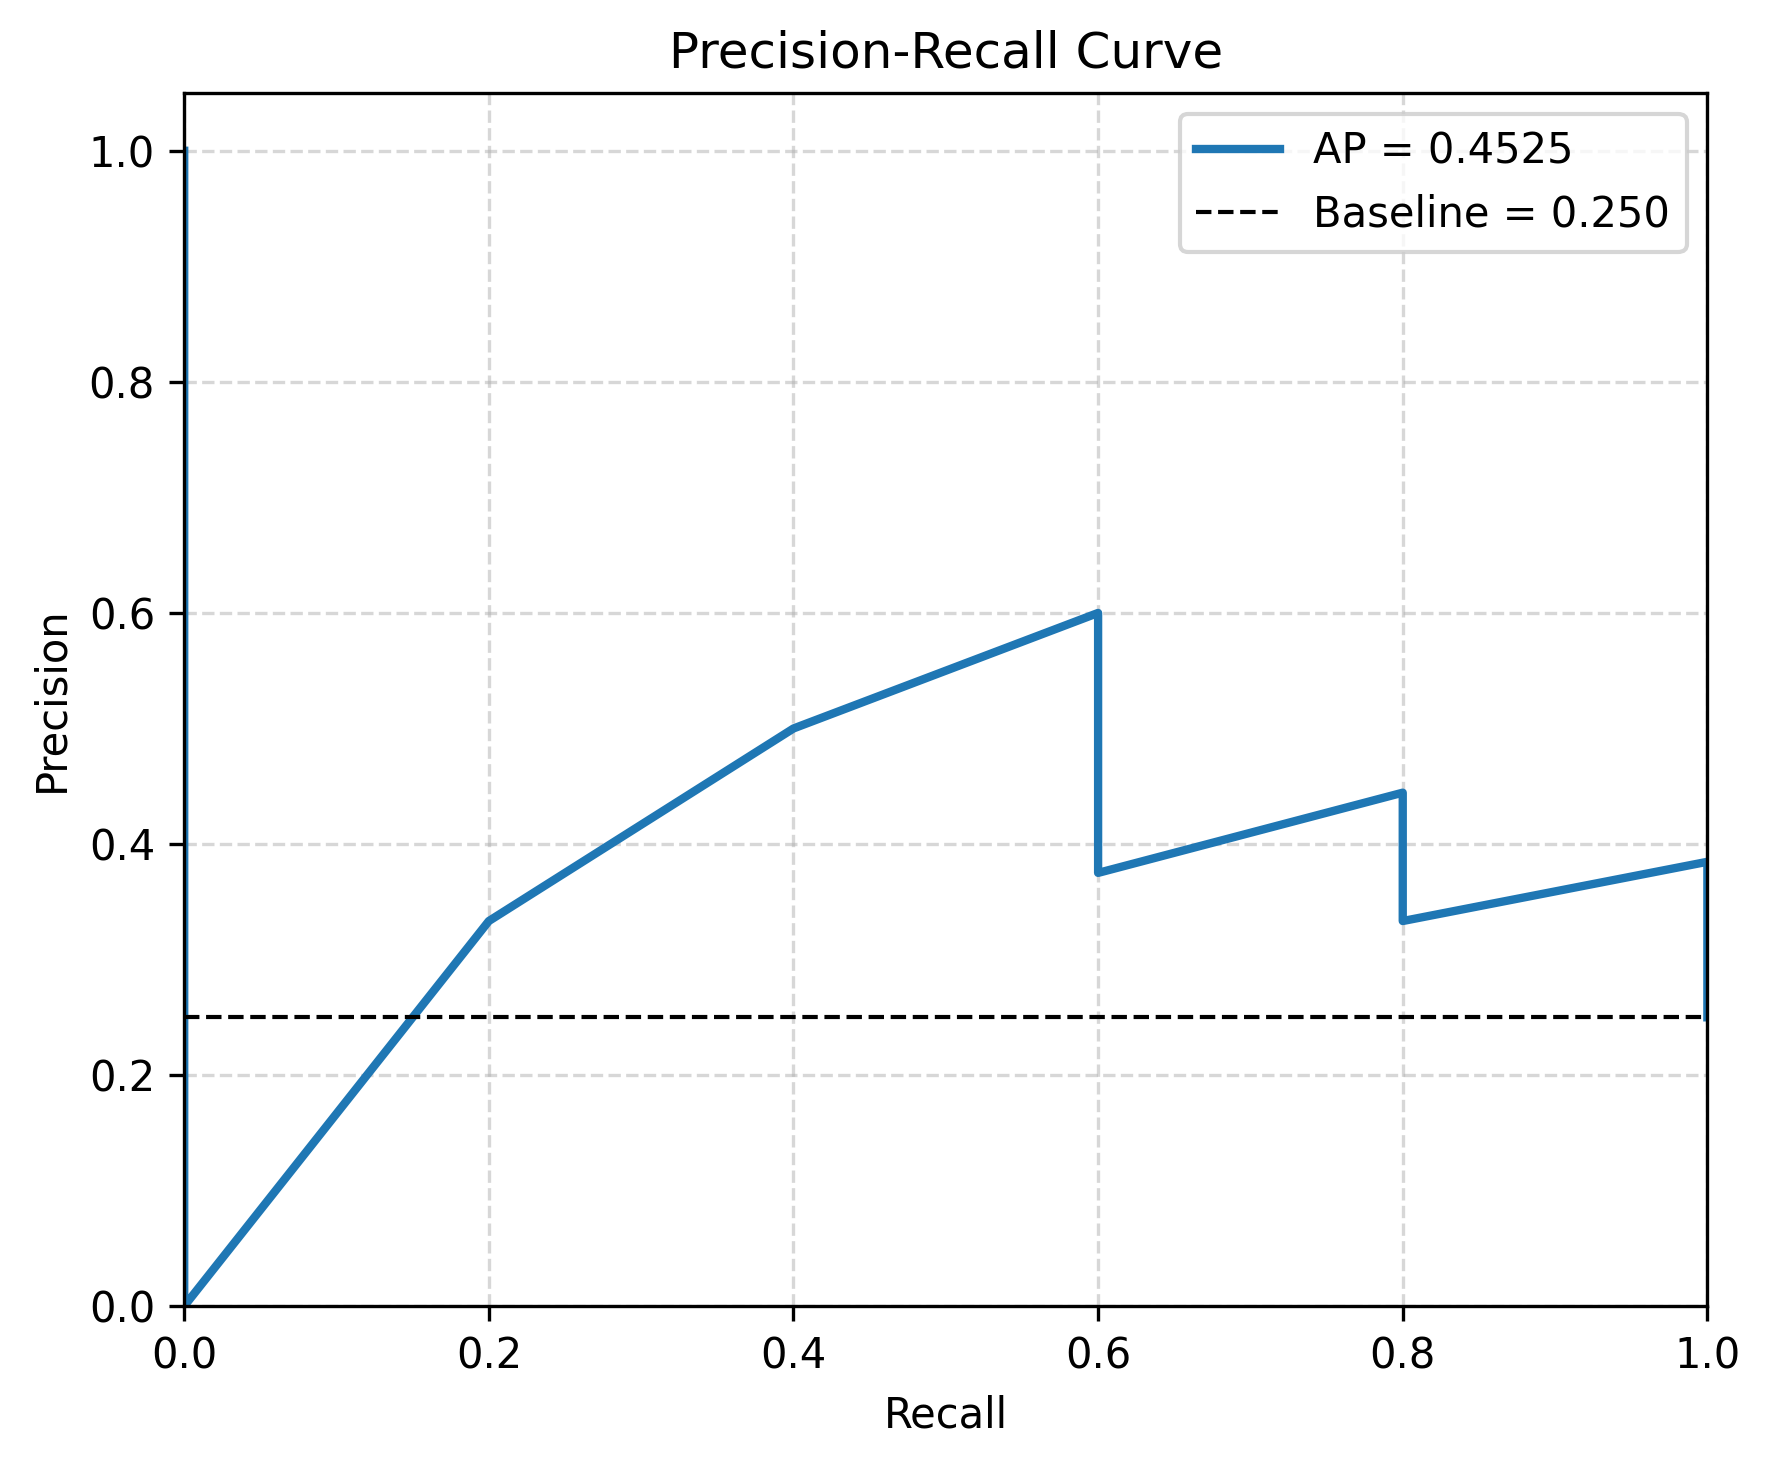

In [6]:
display(Image(filename=str(FIGURES_DIR / "pr_curve.png")))